<a href="https://colab.research.google.com/github/yshzjq/Step-2.Statistical_Thinking-Machine-Learning/blob/main/Step%202.%20%ED%86%B5%EA%B3%84%EC%A0%81%20%EC%82%AC%EA%B3%A0%EC%99%80%20%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D%20%EC%9E%85%EB%AC%B8/%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ===== 1단계: 한글 폰트 설치 및 캐시 삭제 =====
#!apt-get install -y fonts-nanum > /dev/null 2>&1
#!rm -rf ~/.cache/matplotlib/*


In [2]:
# ===== 2단계: 한글 폰트 적용 (런타임 재시작 후 실행) =====
import matplotlib.pyplot as plt

plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)  # 마이너스 기호 깨짐 방지



In [3]:
import pandas as pd

df = pd.read_csv('ad_daily_stats.csv')


In [4]:
df.shape

(66, 11)

In [5]:
df.head()

,날짜,클릭수,전환수,기타비용,광고비,리워드비용,매체수익,전환율,클릭당비용,전환당비용,수익률
0,2025-01-01,17408,2786,994735,1058443,734012,739883,16.00,61.0,380.0,69.90
1,2025-01-02,85994,28793,5965048,6007222,3842790,4287841,33.48,70.0,209.0,71.38
2,2025-01-03,99779,33361,6458117,6494903,4285555,4581081,33.43,65.0,195.0,70.53
3,2025-01-04,100426,32046,5757950,5801526,3935802,4215936,31.91,58.0,181.0,72.67
4,2025-01-05,122833,30881,5589115,5610973,3796656,4053501,25.14,46.0,182.0,72.24


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      66 non-null     object 
 1   클릭수     66 non-null     int64  
 2   전환수     66 non-null     int64  
 3   기타비용    66 non-null     int64  
 4   광고비     66 non-null     int64  
 5   리워드비용   66 non-null     int64  
 6   매체수익    66 non-null     int64  
 7   전환율     66 non-null     float64
 8   클릭당비용   66 non-null     float64
 9   전환당비용   66 non-null     float64
 10  수익률     66 non-null     float64
dtypes: float64(4), int64(6), object(1)
memory usage: 5.8+ KB


In [7]:
# 날짜 컬럼 제외하고 상관행렬 계산
corr_matrix = df.drop('날짜', axis=1).corr()


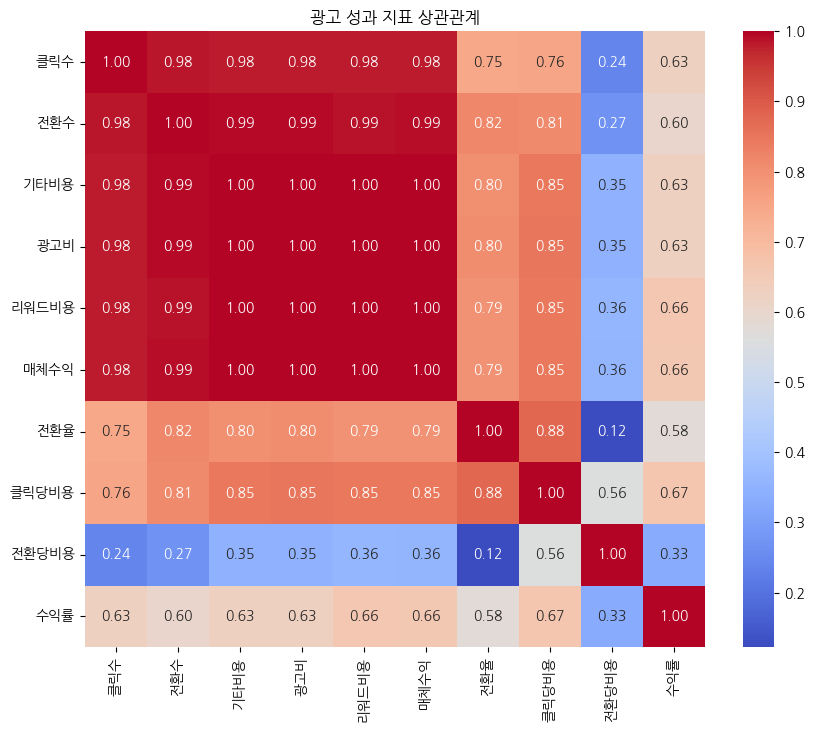

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('광고 성과 지표 상관관계')
plt.show()

In [12]:
# 수익률과의 상관관계를 내림차순 정렬

top3 = corr_matrix['전환율'].sort_values(ascending=False).drop('전환율').head(3)
corr_matrix['전환율'].sort_values(ascending=False).drop('전환율').head(3)

,전환율
클릭당비용,0.876644
전환수,0.818165
광고비,0.804948


In [10]:
print("전환율 기준 상관관계 Top 3")
for i, (col, corr) in enumerate(top3.items(), start=1):
    print(f"{i}위: {col} ({corr:.2f})")

전환율 기준 상관관계 Top 3
1위: 클릭당비용 (0.88)
2위: 전환수 (0.82)
3위: 광고비 (0.80)
